In [59]:
from pathlib import Path
import pandas as pd
from scipy.stats import ttest_ind, boxcox, shapiro, gaussian_kde
import numpy as np
from matplotlib import pyplot as plt

import scienceplots
plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"mathtext.default": "regular"})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
!pwd

/Users/magnus/repos/waam-e2e/e2e


In [2]:
data_folder = Path("/Users/magnus/repos/ml-footprint-pred/paper1/")

In [3]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlim(0.5, len(labels) + 0.5)

def plot_two_violions(desc, labels, dataset):
    cm = 1 / 2.54
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)
    pos = np.arange(0, 2)
    v1 = ax.violinplot(dataset=dataset, positions=pos+1, widths=0.5, showextrema=False, showmedians=True)
    
    med1 = v1['cmedians']
    med1.set_color('black')
    med1.set_linestyle('-')
    
    ax.set_ylabel(desc["y-axis"])
    ax.set_ylim(0, 1.0)
    set_axis_style(ax, labels)
    plt.show()
    return fig

In [244]:
def plot_two_histograms(desc, labels, dataset):
    cm = 1 / 2.54
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(18 * cm, 10 * cm), dpi=600, sharex=True, gridspec_kw={"height_ratios": [6, 1, 6, 1]},)
    
    kde_1 = gaussian_kde(dataset[0])
    x_range_1 = np.linspace(min(dataset[0]), max(dataset[0]), 500)
    ax1.plot(x_range_1, kde_1(x_range_1), color='black', label="density estimate")
    # ax1.hist(dataset[0], bins=20, density=True, histtype='step', cumulative=False, label=labels[0])
    ax2.scatter(dataset[0], [0.01]*len(dataset[0]), marker='.', alpha=0.5)
    # no y ticks on ax2
    ax2.set_yticks([])
    
    kde_2 = gaussian_kde(dataset[1])
    x_range_2 = np.linspace(min(dataset[1]), max(dataset[1]), 500)
    ax3.plot(x_range_2, kde_2(x_range_2), color='black')
    # ax2.hist(dataset[1], bins=20, density=True, histtype='step', cumulative=False, label=labels[1])
    ax4.set_yticks([])
    ax4.scatter(dataset[1], [0.01]*len(dataset[1]), marker='.', alpha=0.5, label="data points")
    
    ax1.set_position([0.1, 0.7, 0.8, 0.2])  # [left, bottom, width, height]
    ax2.set_position([0.1, 0.64, 0.8, 0.05])
    ax3.set_position([0.1, 0.35, 0.8, 0.2])
    ax4.set_position([0.1, 0.29, 0.8, 0.05])
    
    # plot mean and median in to each axis
    ax1.axvline(np.median(dataset[0]), color='red', linestyle='-.', linewidth=0.75, label=f"median")
    # ax1.axvline(np.median(dataset[0]) - np.std(dataset[0]), color='red', linestyle=':', linewidth=0.75)
    # ax1.axvline(np.median(dataset[0]) + np.std(dataset[0]), color='red', linestyle=':', linewidth=0.75)
    
    ax3.axvline(np.median(dataset[1]), color='red', linestyle='-.', linewidth=0.75)
    # ax3.axvline(np.median(dataset[1]) - np.std(dataset[1]), color='red', linestyle=':', linewidth=0.75)
    # ax3.axvline(np.median(dataset[1]) + np.std(dataset[1]), color='red', linestyle=':', linewidth=0.75)
    
    ax1.set_ylabel(desc["y-axis-1"])
    ax3.set_ylabel(desc["y-axis-2"])
    ax4.set_xlabel(desc["x-axis"])
    
    # set x label
    
    # place legend of all axis combined in one below ax4
    lines, labels = ax1.get_legend_handles_labels()
    # li3, la3 = ax3.get_legend_handles_labels()
    li4, la4 = ax4.get_legend_handles_labels()
    
    # lines.append(li3)
    lines.append(li4[0])
    # labels.append(la3)
    labels.append(la4[0])
    # add manual lable to legend
    ax4.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -1.7), ncol=3)
    # make text smaller for legend
    plt.setp(ax4.get_legend().get_texts(), fontsize='small')
    # no box around legend
    ax4.get_legend().get_frame().set_linewidth(0.0)
    return fig

In [245]:
base = Path("outputs/mc/")
folder = Path("20231009-143238-eternal-fire-742") 
run_name = "-".join(str(folder).split("-")[-3::])
trues = np.loadtxt(base / folder / "ys.csv", delimiter=",")
preds = np.loadtxt(base / folder/ "mean_predictions.csv", delimiter=",")

In [246]:
from scipy.spatial.distance import cdist
modhaussdorff = []

x = np.arange(0, 90 / 10, 0.1)

for true, pred in zip(trues, preds):
    
    xa = np.array(list(zip(x, true)))
    xb = np.array(list(zip(x, pred)))
    
    dist = cdist(xa, xb)
    mins = np.min(dist, axis=1)
    
    modhaussdorff.append((np.median(mins)))

In [247]:
# b2b_resnet_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv")
b2b_perfect_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Perfect_shape:Energy2.csv")

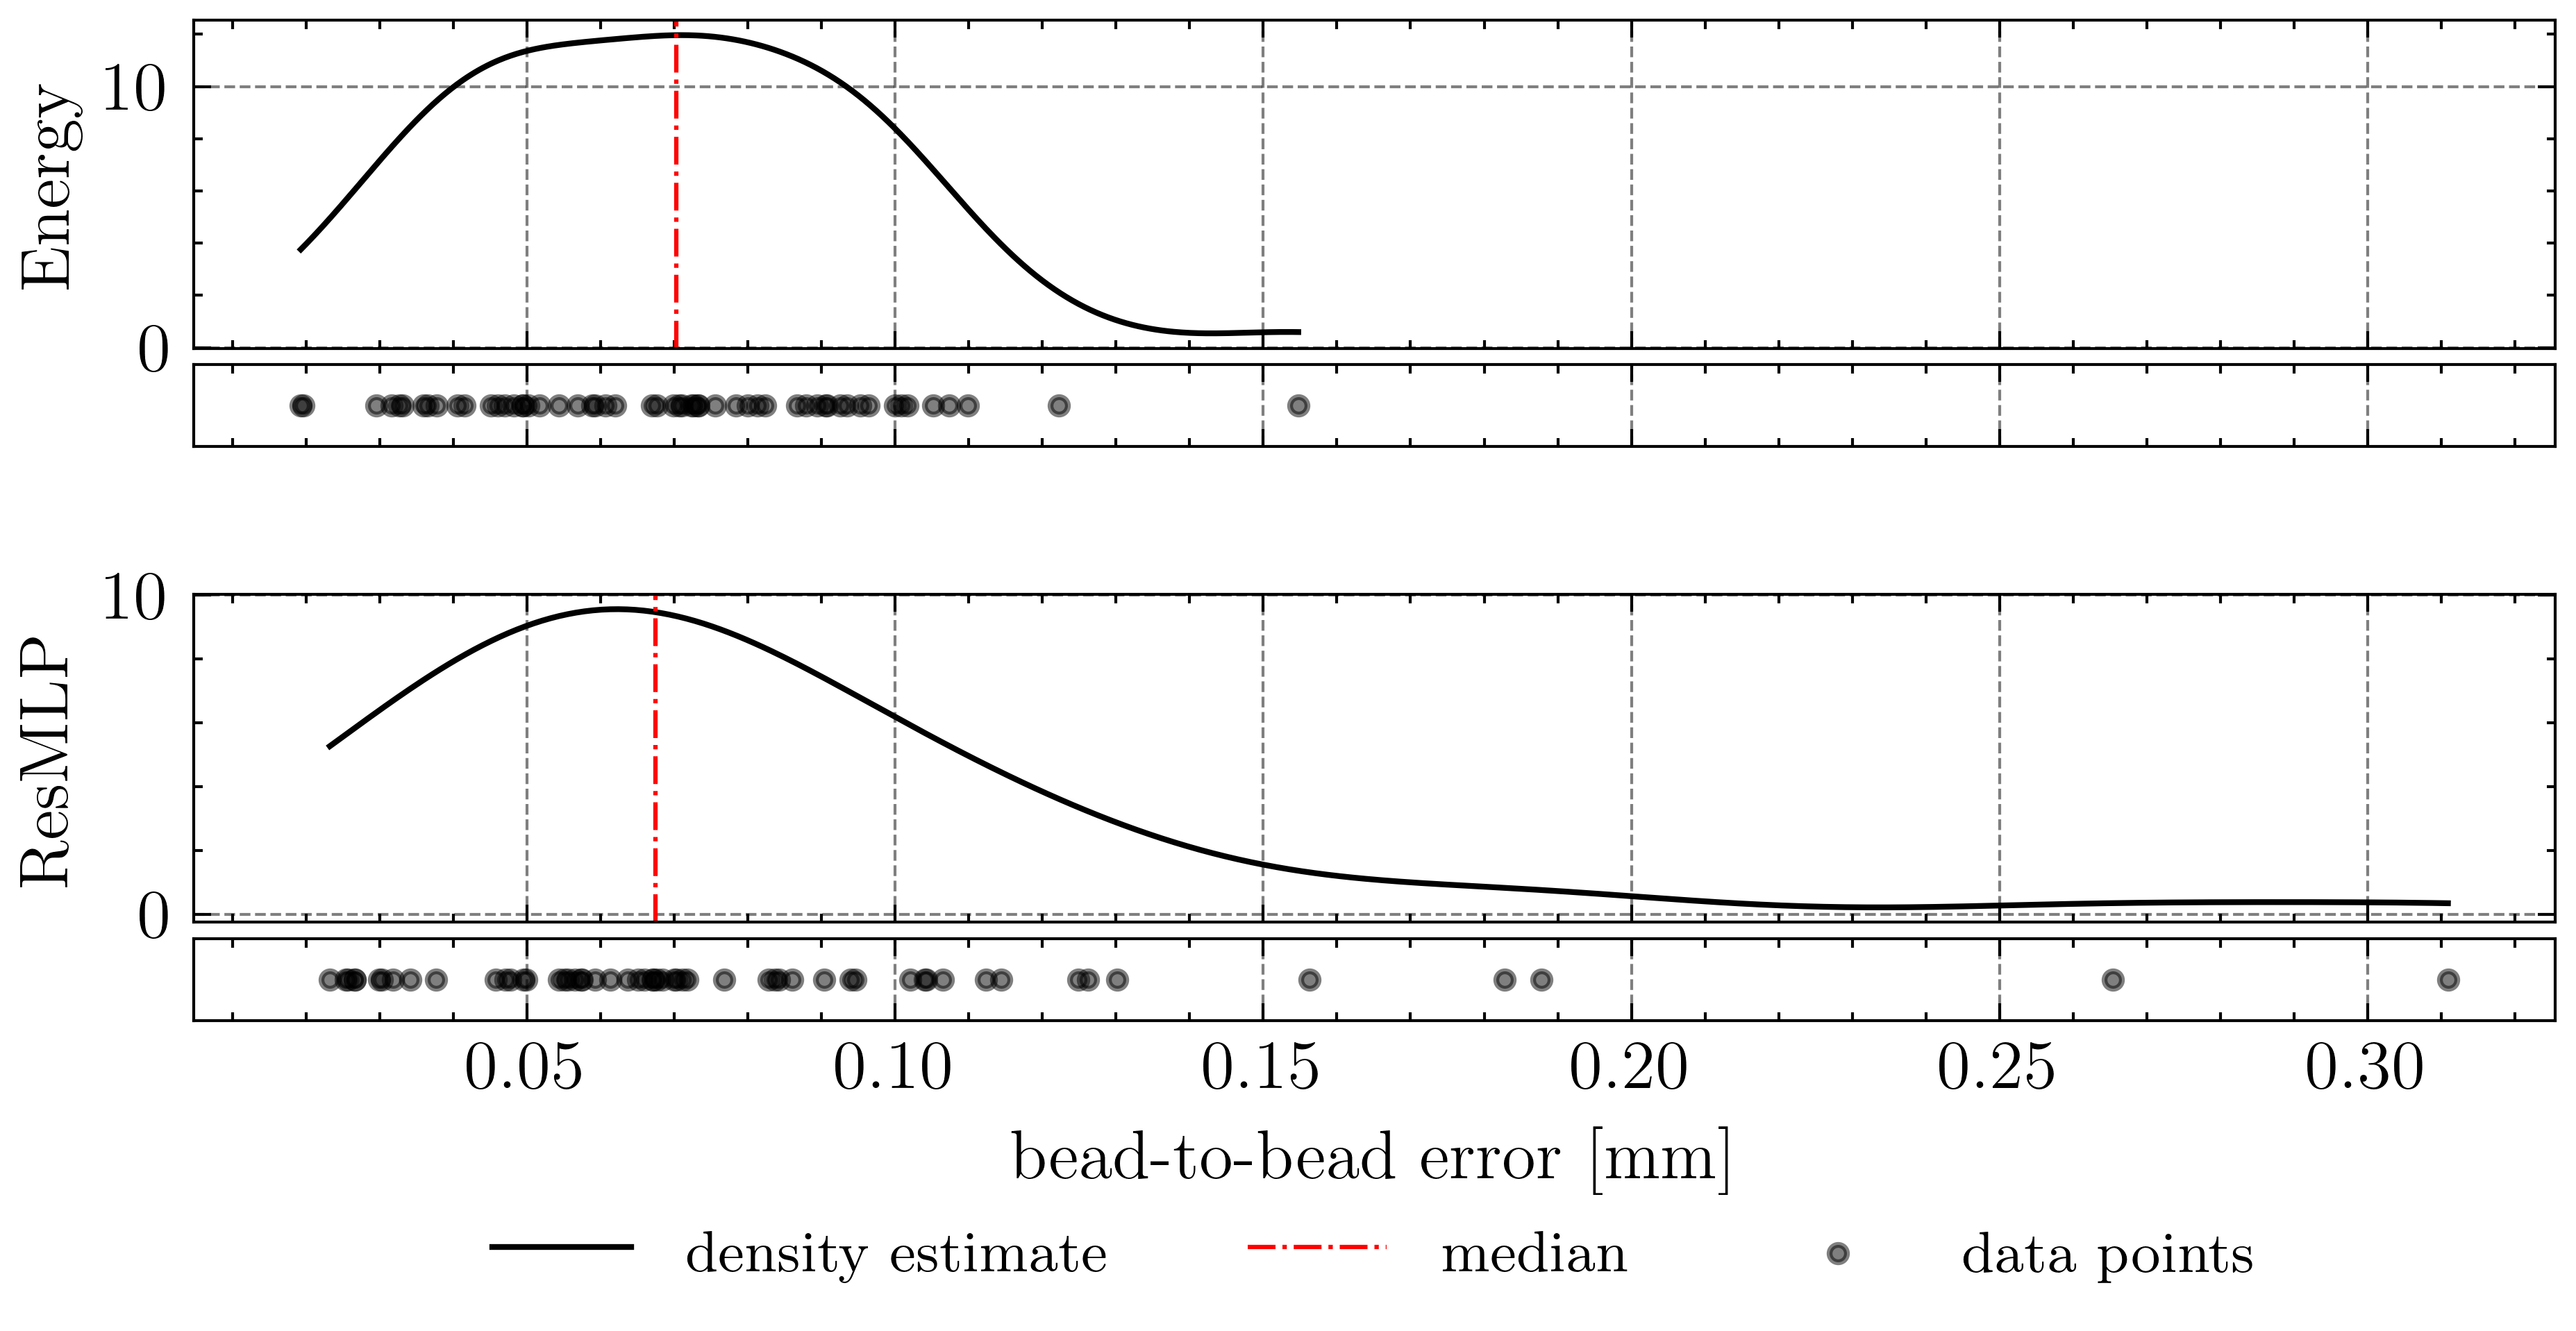

In [248]:
desc = {
    "title": "",
    "x-axis": "",
    "y-axis": "bead-to-bead error $[\mathrm{mm}]$"
}

labels = ["Energy+measured", "LSTM+measured"]

desc = {
    "title": "",
    "x-axis": "bead-to-bead error $[\mathrm{mm}]$",
    "y-axis-1": "Energy",
    "y-axis-2": "ResMLP",
}
# plot_two_violions(desc, labels, [np.array(b2b_perfect_energy), np.array(modhaussdorff)])
fig = plot_two_histograms(desc, labels, [np.array(b2b_perfect_energy), np.array(modhaussdorff)])

In [249]:
# save plot to desktop
desktop = Path("/Users/magnus/Desktop/")
folder = Path("graphics/results/")
fname = Path(f"b2b_hausdorff_{run_name}_vs_energy.png")
fig.savefig(desktop / folder / fname, bbox_inches='tight')

In [94]:
# comput and print out median, mean, and std for both samples
print(f"Median of b2b_perfect_energy: {np.median(b2b_perfect_energy):.4f}")
print(f"Median of modhaussdorff: {np.median(modhaussdorff):.4f}")
print(" ")

print(f"Mean of b2b_perfect_energy: {np.mean(b2b_perfect_energy):.4f}")
print(f"Mean of modhaussdorff: {np.mean(modhaussdorff):.4f}")
print(" ")

print(f"Std of b2b_perfect_energy: {np.std(b2b_perfect_energy):.4f}")
print(f"Std of modhaussdorff: {np.std(modhaussdorff):.4f}")


Median of b2b_perfect_energy: 0.0703
Median of modhaussdorff: 0.0674
 
Mean of b2b_perfect_energy: 0.0689
Mean of modhaussdorff: 0.0814
 
Std of b2b_perfect_energy: 0.0275
Std of modhaussdorff: 0.0542


In [31]:
# Generate non-normal data for the example
np.random.seed(42)
sample_1 = modhaussdorff
sample_2 = b2b_perfect_energy

# Apply Box-Cox transformation
sample_1_transformed, _ = boxcox(sample_1)
sample_2_transformed, _ = boxcox(sample_2)

# Check normality using Shapiro-Wilk test
_, p_value_1 = shapiro(sample_1_transformed)
_, p_value_2 = shapiro(sample_2_transformed)

if p_value_1 > 0.05 and p_value_2 > 0.05:
    print("Both transformed samples appear to be normally distributed.")
else:
    print("One or both transformed samples do not appear to be normally distributed.")

# Conduct the t-test for independent samples on transformed data
t_stat, p_value = ttest_ind(sample_1_transformed, sample_2_transformed)

# Choose a significance level
alpha = 0.05

# Make a decision based on the p-value
if p_value < alpha:
    print(f"Reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are statistically different.")
else:
    print(f"Fail to reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are not statistically different.")

Both transformed samples appear to be normally distributed.
Reject the null hypothesis (p-value = 0.0000)
The means of the two transformed samples are statistically different.
